# Phase 02 — Data Cleaning & Integration

## Education and Income Inequality: A Cross-Country Panel Analysis

This notebook is the portfolio-facing artefact of Phase 02. It documents
the construction of the analytical panel — `data/processed/panel.csv` —
from the raw layer Phase 01 deposited under `data/raw/`. It records the
five design decisions taken at the start of the phase, walks through
the integration pipeline, and characterises the missingness that will
shape every downstream specification.

- **Inputs.** WB WDI long-format file (18 indicators × all entities),
  WB country metadata, UNDP HDR composite indices.
- **Output.** A 7,378-row × 24-column country-year panel covering 217
  sovereign and near-sovereign states, 1990–2023.
- **Scope reference.** [`docs/project_scope.md`](../docs/project_scope.md)
- **Phase 01 reference.** [`notebooks/01_data_collection.ipynb`](01_data_collection.ipynb)

The heavy lifting — long-format extraction, concatenation, pivot,
metadata attachment, and missingness reporting — lives in the step
scripts under `scripts/phase02_s*.py`. This notebook reads the panel
those scripts produce and presents the result in narrative form.

*Date: 2026-04-25*


## 2. Setup


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project's src/ package importable from a notebook
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.manifest import load_manifest, manifest_variable_order
from src.country_metadata import load_country_metadata

# Paths
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
PROC_DIR      = PROJECT_ROOT / "data" / "processed"
MANIFEST_PATH = RAW_DIR / "manifest.yaml"
META_PATH     = RAW_DIR / "world_bank" / "wb_country_metadata.csv"
PANEL_PATH    = PROC_DIR / "panel.csv"

# Scope window
START_YEAR, END_YEAR = 1990, 2023
N_YEARS = END_YEAR - START_YEAR + 1

# Fail fast if the panel hasn't been built
missing = [p for p in (MANIFEST_PATH, META_PATH, PANEL_PATH) if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Required files are missing. Run the Phase 02 step scripts first:\n"
        "  python scripts/phase02_s01_document_decisions.py\n"
        "  python scripts/phase02_s02_build_intermediate_long.py\n"
        "  python scripts/phase02_s03_concat_master_long.py\n"
        "  python scripts/phase02_s04_pivot_to_wide_panel.py\n"
        "  python scripts/phase02_s05_missingness_report.py\n"
        f"Missing: {[str(p) for p in missing]}"
    )

print(f"Project root : {PROJECT_ROOT}")
print(f"Panel        : {PANEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Window       : {START_YEAR}-{END_YEAR} ({N_YEARS} years)")


Project root : C:\Users\kotae\Documents\Portfolio\project\Project 4\education-inequality-analysis
Panel        : data\processed\panel.csv
Window       : 1990-2023 (34 years)


## 3. Design Decisions

Phase 02 opens with five design choices that propagate through every
subsequent phase. They were recorded in `PROJECT_LOG.md` before any
integration code was written.

| # | Decision | Rationale |
|---|---|---|
| 1 | Keep the analytical window 1990–2023 | Specification-level sample restrictions handled at modelling time, not at panel construction |
| 2 | Retain the 22 WB-only countries with `mys = NaN` | Listwise deletion at modelling time will drop them automatically from any spec that requires `mys` |
| 3 | Listwise deletion default; per-specification N reporting | Multiple imputation rejected because Gini missingness concentrates in low-income countries (plausibly MNAR) |
| 4 | Apply log transforms at modelling time, not in the panel | EDA in Phase 03 sees genuine skewed distributions; Phase 05 owns `np.log` |
| 5 | No Gini provenance metadata column | Adding a partially-populated PIP method-type column would pollute the panel; the caveat is deferred to Phase 07 |

The principle running through these is **discard data only once, at
the latest stage**. Trimming the window or imputing values during
cleaning forecloses analyses that the panel could otherwise support at
near-zero storage cost.


## 4. Pipeline

Five step scripts feed each other in series. Each was evaluated against
the PROJECT_WORKFLOW.md Definition of Done before the next step began.

| Step | Script | Output |
|------|--------|--------|
| 01 | `phase02_s01_document_decisions.py`        | PROJECT_LOG.md entry |
| 02 | `phase02_s02_build_intermediate_long.py`   | `data/processed/wb_long.csv`, `hdr_long.csv` |
| 03 | `phase02_s03_concat_master_long.py`        | `data/processed/panel_long.csv` |
| 04 | `phase02_s04_pivot_to_wide_panel.py`       | **`data/processed/panel.csv`** |
| 05 | `phase02_s05_missingness_report.py`        | `outputs/tables/phase02_missingness_report.csv`, `outputs/figures/phase02_missingness_matrix.png` |

This notebook reads the final artefact (`panel.csv`) and recomputes
the diagnostics inline, so running it is itself a verification of the
pipeline.


## 5. The Integrated Panel

The wide panel has one row per (iso3, year), with metadata columns
followed by the 19 declared variables in canonical order. Reindexing
onto the complete 217 × 34 = 7,378-row Cartesian grid ensures missing
observations are explicit NaN rows rather than missing rows — this is
what makes per-variable and joint missingness analysis well-defined.


In [2]:
panel = pd.read_csv(PANEL_PATH)
manifest = load_manifest(MANIFEST_PATH)
VAR_ORDER = manifest_variable_order(manifest)

print(f"panel shape         : {panel.shape}")
print(f"unique iso3         : {panel['iso3'].nunique()}")
print(f"unique years        : {panel['year'].nunique()}")
print(f"year range          : {int(panel['year'].min())}-{int(panel['year'].max())}")
print(f"declared variables  : {len(VAR_ORDER)}")
print()

panel.head(8)


panel shape         : (7378, 24)
unique iso3         : 217
unique years        : 34
year range          : 1990-2023
declared variables  : 19



,iso3,year,country_name,region_name,income_level_name,gini,enrol_primary,enrol_secondary,enrol_tertiary,enrol_secondary_female,...,unemployment_rate,inflation_cpi,population,urban_population_pct,trade_openness,gov_expenditure_gdp,agri_value_added_gdp,manu_value_added_gdp,services_value_added_gdp,mean_years_schooling
0,ABW,1990,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,5.836688,62753.0,65.432816,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,1991,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,5.555556,65896.0,65.400922,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,1992,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,3.873375,69005.0,65.390589,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,1993,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,5.215560,73685.0,65.384467,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,1994,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,6.311080,77595.0,65.380048,NaN,NaN,NaN,NaN,NaN,NaN
5,ABW,1995,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,3.361391,79805.0,65.376703,171.362098,19.966159,0.505922,2.517766,81.036379,NaN
6,ABW,1996,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,3.225288,83021.0,65.373804,175.344130,20.161943,0.485830,2.510121,80.975304,NaN
7,ABW,1997,Aruba,Latin America & Caribbean,High income,NaN,NaN,NaN,NaN,NaN,...,NaN,2.999948,86301.0,65.370721,168.781911,23.595915,0.429978,2.477024,79.588257,NaN


## 6. Per-Variable Coverage

The first analytical question is which variables observe a meaningful
fraction of the 7,378 country-year cells. The block below recomputes,
against the wide panel, the per-variable summary that Step 05 wrote to
`outputs/tables/phase02_missingness_report.csv`.


In [3]:
def per_variable_coverage(panel_df, variables, n_years):
    n_total = len(panel_df)
    rows = []
    for var in variables:
        col = panel_df[var]
        observed = col.notna()
        per_country = panel_df.assign(_obs=observed).groupby("iso3")["_obs"].sum()
        observed_years = panel_df.loc[observed, "year"]
        rows.append({
            "variable": var,
            "n_observed": int(observed.sum()),
            "pct_observed": round(100 * observed.sum() / n_total, 1),
            "countries_any": int((per_country > 0).sum()),
            "countries_full": int((per_country == n_years).sum()),
            "first_year": int(observed_years.min()) if len(observed_years) else None,
        })
    return (
        pd.DataFrame(rows)
        .sort_values("pct_observed", ascending=False)
        .reset_index(drop=True)
    )


coverage = per_variable_coverage(panel, VAR_ORDER, N_YEARS)
coverage


,variable,n_observed,pct_observed,countries_any,countries_full,first_year
0,urban_population_pct,7378,100.0,217,217,1990
1,population,7378,100.0,217,217,1990
2,gdp_per_capita_usd,7014,95.1,214,188,1990
3,gdp_per_capita_ppp,6597,89.4,199,184,1990
4,agri_value_added_gdp,6218,84.3,206,121,1990
5,unemployment_rate,6167,83.6,187,0,1991
6,mean_years_schooling,6081,82.4,193,152,1990
7,services_value_added_gdp,6074,82.3,205,114,1990
8,inflation_cpi,5841,79.2,193,120,1990
9,manu_value_added_gdp,5837,79.1,203,100,1990


Three patterns dominate the coverage table:

1. **Gini is the binding constraint.** At 30.0% completeness with only
   3 countries having all 34 years observed, any specification that
   includes Gini will inherit this density. Downstream listwise samples
   land in the 1,000–2,000 row range (see §8).
2. **`mean_years_schooling` is denser than every enrolment measure**
   (82.4% vs 51–69%). The HDR's imputation across missing years gives
   `mys` an effective coverage that the raw UIS enrolment series — even
   when mirrored through the WB API — does not match.
3. **`unemployment_rate`'s first observed year is 1991.** The ILO's
   modeled series begins one year inside the Scope window. Any 1990
   cross-section using this variable will fail; FE specifications are
   unaffected since they retain only post-1991 observations regardless.

The `countries_full` column is more informative than `countries_any`
for fixed-effects estimation: a country with 5 observed years
contributes 5 within-country differences to the estimator, not 34.


## 7. Spatiotemporal Missingness — Gini

Density numbers tell us how much is missing. The heatmap below tells
us *where* and *when*. Countries are ordered by World Bank region;
black marks an observed Gini value in that country-year cell.


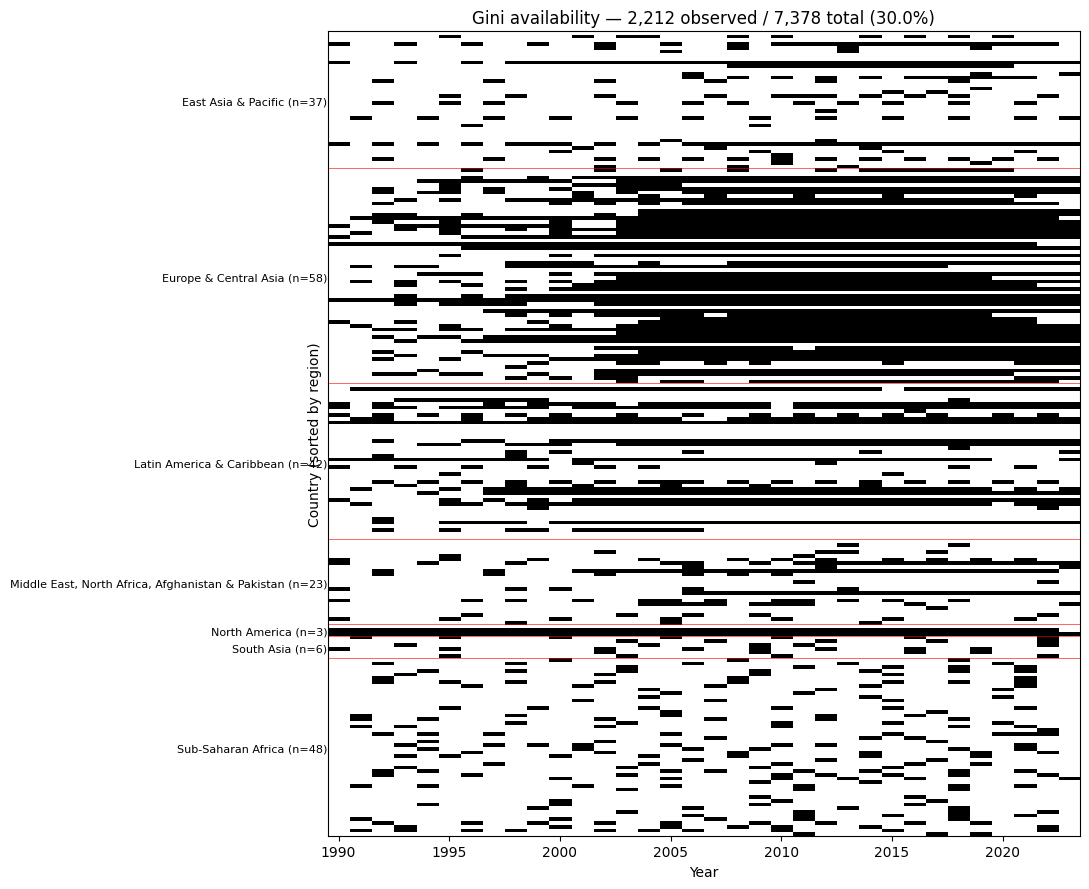

In [4]:
country_meta = load_country_metadata(META_PATH)
order_df = country_meta.sort_values(["region_name", "iso3"]).reset_index(drop=True)
ordered_iso3 = order_df["iso3"].tolist()

gini_matrix = (
    panel.pivot(index="iso3", columns="year", values="gini")
    .notna()
    .astype(int)
    .reindex(ordered_iso3)
)

fig, ax = plt.subplots(figsize=(11, 9))
ax.imshow(
    gini_matrix.values,
    aspect="auto",
    cmap="binary",
    vmin=0, vmax=1,
    interpolation="nearest",
)
ax.set_xticks(range(0, N_YEARS, 5))
ax.set_xticklabels(range(START_YEAR, END_YEAR + 1, 5))
ax.set_xlabel("Year")
ax.set_ylabel("Country (sorted by region)")
ax.set_yticks([])

n_obs = int(gini_matrix.values.sum())
n_tot = int(gini_matrix.size)
ax.set_title(
    f"Gini availability — {n_obs:,} observed / {n_tot:,} total "
    f"({100 * n_obs / n_tot:.1f}%)"
)

# Region boundaries with labels at midpoints
region_starts = order_df[
    order_df["region_name"].ne(order_df["region_name"].shift())
].index.tolist()
region_starts_with_end = region_starts + [len(order_df)]
for boundary in region_starts[1:]:
    ax.axhline(boundary - 0.5, color="red", linewidth=0.6, alpha=0.7)
for i, start in enumerate(region_starts_with_end[:-1]):
    end = region_starts_with_end[i + 1]
    midpoint = (start + end) / 2
    region = order_df.iloc[start]["region_name"].strip()
    n_in_region = end - start
    ax.text(
        -0.5, midpoint,
        f"{region} (n={n_in_region})",
        va="center", ha="right",
        fontsize=8,
    )

plt.tight_layout()
plt.show()


The geographic structure of Gini missingness is hard to mistake. The
top half of the plot — Europe & Central Asia, with strong post-2000
density, and the small but uniformly-black North America block — shows
what dense Gini coverage looks like. The bottom — Sub-Saharan Africa
— is overwhelmingly white, with sparse spot observations spread across
decades. South Asia and the Middle East / North Africa group sit in
between, with country-by-country heterogeneity rather than systematic
coverage.

This pattern is the visual case for the missingness strategy adopted in
§3 (Decision 3). Multiple imputation under MAR — assuming that
unobserved Gini values resemble observed ones once controls are
conditioned on — would manufacture a fictional inequality landscape
for low-income countries by inheriting patterns from countries that
are not demographically or economically comparable. Phase 07's causal
discussion will return to this as a named threat to identification.


## 8. Joint Listwise Sample Sizes

Per-variable density bounds the analytical sample only loosely; what
matters for any given specification is the joint pattern of non-null
values across all variables in that specification. The four
illustrative specifications below frame the range of analytical sample
sizes Phase 05 will navigate.


In [5]:
SPECIFICATIONS = {
    "all_19_variables": VAR_ORDER,
    "core_education_economic": [
        "gini",
        "enrol_primary", "enrol_secondary", "enrol_tertiary",
        "gdp_per_capita_ppp", "population", "urban_population_pct",
    ],
    "minimal_with_mys": [
        "gini", "mean_years_schooling",
        "gdp_per_capita_ppp", "unemployment_rate",
    ],
    "no_gini_diagnostic": [
        "enrol_primary", "enrol_secondary", "enrol_tertiary",
        "gdp_per_capita_ppp", "population", "urban_population_pct",
    ],
}

n_total = len(panel)
rows = []
for name, vars_ in SPECIFICATIONS.items():
    complete = panel[vars_].notna().all(axis=1)
    rows.append({
        "specification": name,
        "n_variables": len(vars_),
        "n_complete_rows": int(complete.sum()),
        "pct_of_panel": round(100 * complete.sum() / n_total, 1),
        "countries_complete": int(panel.loc[complete, "iso3"].nunique()),
    })

joint = pd.DataFrame(rows)
joint


,specification,n_variables,n_complete_rows,pct_of_panel,countries_complete
0,all_19_variables,19,1041,14.1,112
1,core_education_economic,7,1423,19.3,140
2,minimal_with_mys,4,2122,28.8,160
3,no_gini_diagnostic,6,3041,41.2,186


The contrast between `core_education_economic` (1,423 rows, includes
Gini) and `no_gini_diagnostic` (3,041 rows, excludes Gini) is the most
diagnostic comparison in this notebook. **Removing Gini more than
doubles the surviving sample** — the numerical confirmation of what
the heatmap showed visually.

These specifications are illustrative bounds, not modelling commitments.
Phase 05 will define the canonical specifications, run the Hausman test
to choose between fixed effects and random effects, and report N and
country coverage explicitly for each estimated model.


## 9. Limitations of the Panel

The panel is auditable and reproducible, but is constrained by what
the underlying sources provide:

- **Gini measurement heterogeneity.** The WB Gini series concatenates
  consumption-based and income-based national surveys with different
  reference units, equivalence scales, and welfare measures. Within-
  country fixed effects absorb the time-invariant component of this
  heterogeneity but not changes in survey methodology over time.
  Flagged in `docs/project_scope.md` §12; revisited in Phase 07.
- **Selection bias from Gini missingness.** Per §7, Gini is missing
  non-randomly. No correction is applied here; Phase 07 names this as
  a threat to identification rather than fixing it with imputation.
- **Pre-2000 enrolment sparsity.** Three enrolment variables show a
  density jump around 2000. Specifications relying on enrolment will
  effectively be 2000–2023 panels even though the panel itself spans
  1990–2023.
- **22 high-income territories without `mys`.** Retained per Decision
  2; will drop out of any specification using mean_years_schooling.


## 10. Conclusion

Phase 02 produces the analytical panel that the rest of the project
runs on:

- **One file** (`data/processed/panel.csv`) — 7,378 rows × 24 columns,
  keyed on (iso3, year), with five metadata columns and 19 declared
  variables in canonical order.
- **One missingness report** with per-variable, country-coverage, and
  joint-specification statistics.
- **Five recorded design decisions** documented in `PROJECT_LOG.md`
  and carried forward via this notebook.

### Next

Phase 03 — Exploratory Data Analysis. Distributions, correlations,
time trends, and geographic visualisations of the variables in this
panel, building toward the country clustering of Phase 04 and the
econometric modelling of Phase 05.
